# Team Strenght

## Objective
It is of great interest to quantify team strenght and its effects on scoring. Our main 3 derived statistics for this are :
- Elo Scores
- Availiability Index

In this notebook I will explore the relations each of these have with goals scored.

 ## Libraries

In [10]:
library(tidyverse)
library(car)
library(here)
library(ggpubr)

## ELO Ratins

### Data join

In [11]:
ELO <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "ELOSScores.rds"))
Games <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "FullTeamGames.rds"))
length(setdiff(Games$team_name, ELO$team))

[1] 0

In [12]:
set.seed(2026)

ELOByTournament <- ELO %>%
    pivot_longer(
        cols = starts_with("WC_"),
        names_to = "tournament_year",
        values_to = "elo"
    ) %>%
    mutate(tournament_id = str_replace(tournament_year, "_", "-")) %>%
    select(team, tournament_id, team_ELO = elo)

OpponentELOByTournament <- ELOByTournament %>%
    rename(opponent_name = team, opponent_ELO = team_ELO)

Games <- Games %>%
    rename(team = team_name) %>%
    left_join(ELOByTournament, by = c("team", "tournament_id")) %>%
    left_join(OpponentELOByTournament, by = c("opponent_name", "tournament_id"))

Games %>%
    slice_sample(n=10)

match_id,tournament_id,stage_name,group_stage,goals_against,goals_for,team_id,opponent_id,city_name,team,opponent_name,match_date,match_time,last_game_date,rest_days,team_ELO,opponent_ELO
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<chr>,<date>,<dbl>,<int>,<int>
M-2014-51,WC-2014,round of 16,0,2,1,T-46,T-48,Fortaleza,Mexico,Netherlands,2014-06-29,13:00,2014-06-23,6,1796,2003
M-2010-50,WC-2010,round of 16,0,2,1,T-83,T-32,Rustenburg,United States,Ghana,2010-06-26,20:30,2010-06-23,3,1802,1686
M-2022-03,WC-2022,group stage,1,2,0,T-65,T-48,Doha,Senegal,Netherlands,2022-11-21,19:00,NA,7,1702,1929
M-2018-02,WC-2018,group stage,1,1,0,T-26,T-84,Yekaterinburg,Egypt,Uruguay,2018-06-15,17:00,NA,7,1650,1866
M-2010-58,WC-2010,quarter-finals,0,1,1,T-32,T-84,Johannesburg,Ghana,Uruguay,2010-07-02,20:30,2010-06-26,6,1686,1814
M-2010-56,WC-2010,round of 16,0,0,1,T-73,T-58,Cape Town,Spain,Portugal,2010-06-29,20:30,2010-06-25,4,2094,1874
M-2018-01,WC-2018,group stage,1,0,5,T-62,T-63,Moscow,Russia,Saudi Arabia,2018-06-14,18:00,NA,7,1696,1570
M-2010-16,WC-2010,group stage,1,1,0,T-73,T-75,Durban,Spain,Switzerland,2010-06-16,16:00,NA,7,2094,1792
M-2014-49,WC-2014,round of 16,0,1,1,T-13,T-09,Belo Horizonte,Chile,Brazil,2014-06-28,13:00,2014-06-23,5,1914,2132


[1] 512

### Studying the relationship

`geom_smooth()` using formula = 'y ~ x'


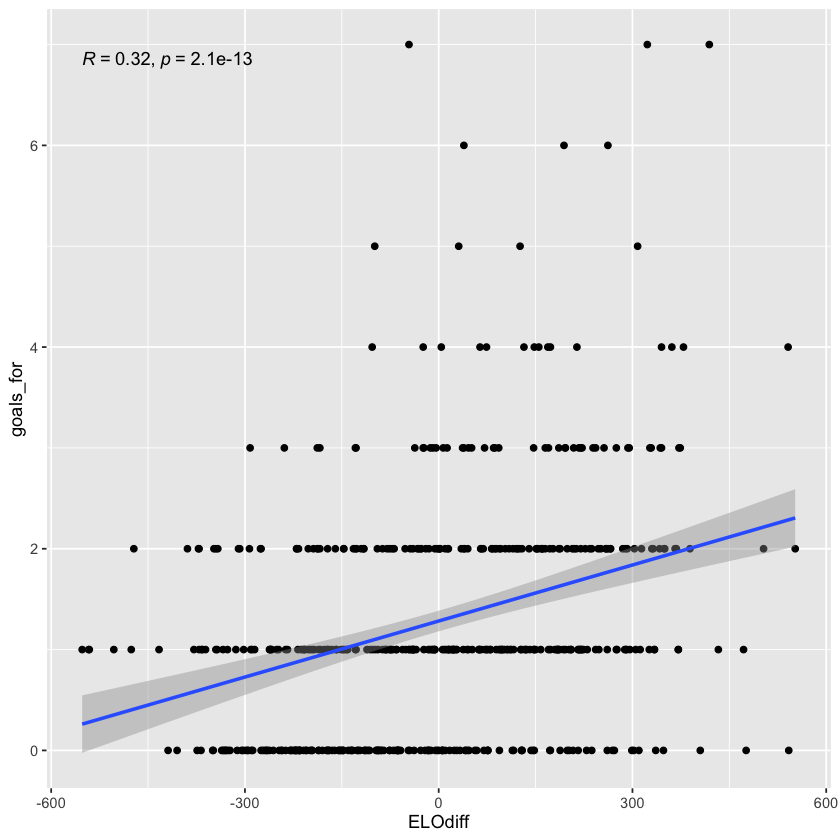

In [13]:
Games %>%
    mutate(ELOdiff = (team_ELO - opponent_ELO)) %>%
        ggplot(aes(x=ELOdiff, y=goals_for)) +
            geom_point() +
                geom_smooth(method="lm", se = TRUE) +
                    stat_cor()

`geom_smooth()` using formula = 'y ~ x'


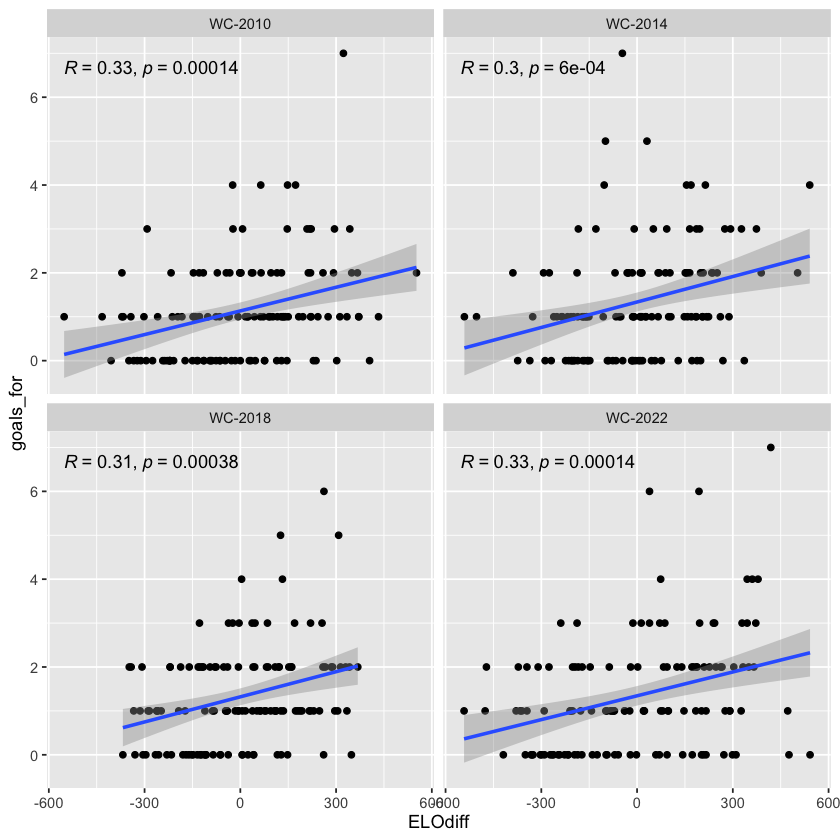

In [14]:
Games %>%
    mutate(ELOdiff = (team_ELO - opponent_ELO)) %>%
        ggplot(aes(x=ELOdiff, y=goals_for)) +
            geom_point() +
                geom_smooth(method="lm", se = TRUE) +
                    stat_cor() +
                        facet_wrap(~ tournament_id)

In [15]:
m1 <- lm(goals_for ~ I(team_ELO-opponent_ELO), Games)
m2 <- glm(goals_for ~ I(team_ELO-opponent_ELO), family=poisson, Games)
m3 <- glm(goals_for ~ poly(I(team_ELO-opponent_ELO),2), family=poisson, Games)

BIC(m1)
BIC(m2)
BIC(m3)

[1] 1636.957

[1] 1479.812

[1] 1485.832

<div style="
    background-color:#111111;
    color:white;
    padding:20px;
    border-radius:10px;
    border-left:6px solid #4CAF50;
    font-family:Arial, sans-serif;
    line-height:1.6;
">

<h2 style="color:white;">📊 Math Check: Poisson Distribution</h2>

<h3 style="color:white;">What is a Poisson Distribution?</h3>

<p>
A Poisson distribution describes a <strong>discrete random variable</strong> that counts the number of times an event occurs within a fixed interval of time, space, or opportunity.
</p>

<p>It is commonly used to model counts such as:</p>

<ul>
<li>Calls received by a call center in an hour</li>
<li>Cars passing through an intersection in a minute</li>
<li>Goals scored by a soccer team in a match</li>
</ul>

<p>
Since goals are count data, the Poisson distribution is a natural starting point for modeling soccer scores.
</p>

<h3 style="color:white;">Why Use a Poisson Model?</h3>

<p>
A Poisson model addresses several issues that would arise if we used a standard linear regression model to predict goals.
</p>

<h4 style="color:white;">1. Goals Are Discrete</h4>

<p>
A team can score 0, 1, 2, or 3 goals, but it cannot score 2.6 goals. The Poisson distribution is specifically designed for count data.
</p>

<h4 style="color:white;">2. Goals Cannot Be Negative</h4>

<p>
A linear regression model can theoretically predict any real number, including impossible values such as −1 goals. A Poisson model always produces non-negative expected counts.
</p>

<h4 style="color:white;">3. Variance Increases with the Mean</h4>

<p>
In ordinary linear regression, we assume constant variance (homoscedasticity). This means the spread of errors is assumed to be roughly the same regardless of the predicted value.
</p>

<p>
For soccer goals, this assumption is often unrealistic. A team expected to score 3 goals typically has more variability than a team expected to score only 0.5 goals.
</p>

<p>
The Poisson distribution naturally captures this relationship.
</p>

<h3 style="color:white;">The Key Poisson Assumption</h3>

<div style="
    text-align:center;
    font-size:24px;
    font-weight:bold;
    padding:15px;
    margin:15px 0;
    background-color:#222222;
    border-radius:8px;
">
λ = E[Y] = Var(Y)
</div>

<p>where:</p>

<ul>
<li><strong>Y</strong> = goals scored by a team</li>
<li><strong>λ</strong> = expected number of goals</li>
</ul>

<p>
This means that the expected number of goals and the variance of goals are assumed to be equal.
</p>

<ul>
<li>If λ = 1, the model assumes a variance of approximately 1.</li>
<li>If λ = 3, the model assumes a variance of approximately 3.</li>
</ul>

<p>
As the expected number of goals increases, the variance increases automatically. This feature makes the Poisson distribution particularly useful for modeling soccer scores.
</p>

<h3 style="color:white;">Important Note</h3>

<div style="
    background-color:#2a1a1a;
    border-left:5px solid #ff9800;
    padding:12px;
    border-radius:5px;
">
The equality <strong>E[Y] = Var(Y)</strong> is an assumption of the Poisson distribution, not a universal law. Real soccer data often exhibit <strong>overdispersion</strong>, meaning the variance is larger than the mean. When this occurs, alternative models such as the Negative Binomial distribution may provide a better fit.
</div>

</div>

## Availability Index

### Data Join

In [16]:
GKind <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "GKind.rds"))
Defind <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "Defind.rds"))
MFind <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "MFind.rds"))
FWind <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "FWind.rds"))

indices <- GKind %>%
    rename(GKInd = inWC) %>%
    left_join(
        Defind %>% rename(DefInd = index),
        by = c("country_of_citizenship", "tournament_id")
    ) %>%
    left_join(
        MFind %>% rename(MFInd = index),
        by = c("country_of_citizenship", "tournament_id")
    ) %>%
    left_join(
        FWind %>% rename(FWInd = index),
        by = c("country_of_citizenship", "tournament_id")
    ) %>%
    rename(team_name = country_of_citizenship)

Games <- Games %>%
    left_join(
        indices,
        by = c(
            "team" = "team_name",
            "tournament_id"
        )
    ) %>%
    left_join(
        indices %>%
            rename(
                OppGKInd  = GKInd,
                OppDefInd = DefInd,
                OppMFInd  = MFInd,
                OppFWInd  = FWInd
            ),
        by = c(
            "opponent_name" = "team_name",
            "tournament_id"
        )
    ) %>%
    select(-contains("value"))

head(Games)

match_id,tournament_id,stage_name,group_stage,goals_against,goals_for,team_id,opponent_id,city_name,team,...,team_ELO,opponent_ELO,GKInd,DefInd,MFInd,FWInd,OppGKInd,OppDefInd,OppMFInd,OppFWInd
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,...,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
M-2010-06,WC-2010,group stage,1,1,0,T-01,T-69,Polokwane,Algeria,...,1580,1673,1,0.7625650,0.7734375,0.7866667,0,0.7354331,1.0000000,0.3014019
M-2010-23,WC-2010,group stage,1,0,0,T-01,T-28,Cape Town,Algeria,...,1580,1985,1,0.7625650,0.7734375,0.7866667,1,0.5984556,1.0000000,0.8333333
M-2010-38,WC-2010,group stage,1,1,0,T-01,T-83,Pretoria,Algeria,...,1580,1802,1,0.7625650,0.7734375,0.7866667,1,0.9594272,0.1391162,0.2013423
M-2010-04,WC-2010,group stage,1,0,1,T-03,T-50,Johannesburg,Argentina,...,1897,1747,0,0.4699358,0.2836364,1.0000000,1,0.5858407,0.0000000,1.0000000
M-2010-18,WC-2010,group stage,1,1,4,T-03,T-71,Johannesburg,Argentina,...,1897,1749,0,0.4699358,0.2836364,1.0000000,NA,NA,NA,NA
M-2010-35,WC-2010,group stage,1,0,2,T-03,T-33,Polokwane,Argentina,...,1897,1782,0,0.4699358,0.2836364,1.0000000,1,1.0000000,0.3112033,0.8273810


### Explore relationship

Since there is a lot of variables I will aply a forward seleciton method using log loss as the selection metric.

<div style="
    background-color:#111111;
    color:white;
    padding:16px;
    border-radius:10px;
    border-left:5px solid #4CAF50;
    font-family:Arial, sans-serif;
    line-height:1.5;
">

<h2 style="color:white;">📉 Math Check: Log Loss</h2>

<p>
Log loss measures how well a probabilistic model predicts the outcome that actually occurred.
</p>

<p>
For a Poisson goal model, the model predicts a value <strong>&lambda;</strong>, then assigns probabilities to each possible goal count:
</p>

<div style="
    text-align:center;
    font-size:20px;
    font-weight:bold;
    padding:10px;
    margin:12px 0;
    background-color:#222222;
    border-radius:8px;
">
P(Y = y | &lambda;)
</div>

<p>
The log loss for one observation is:
</p>

<div style="
    text-align:center;
    font-size:20px;
    font-weight:bold;
    padding:10px;
    margin:12px 0;
    background-color:#222222;
    border-radius:8px;
">
−log(P(actual goals))
</div>

<p>
This means the model is rewarded when it assigns high probability to the number of goals that actually happened, and punished when it assigns low probability to the actual outcome.
</p>

<h3 style="color:white;">How to Interpret It</h3>

<ul>
    <li><strong>Lower log loss is better.</strong></li>
    <li>A log loss of <strong>0</strong> would mean perfect prediction.</li>
    <li>Small improvements matter because log loss is averaged across many games.</li>
</ul>

<p>
For example, if a model assigns a 25% probability to the actual score count, the loss is:
</p>

<div style="
    text-align:center;
    font-size:18px;
    font-weight:bold;
    padding:10px;
    margin:12px 0;
    background-color:#222222;
    border-radius:8px;
">
−log(0.25) = 1.386
</div>

<h3 style="color:white;">In This Project</h3>

<p>
We use log loss to compare Poisson models out of sample. If adding a variable lowers log loss, that variable improved the model's probabilistic prediction of goals.
</p>

<div style="
    background-color:#1f2a1f;
    border-left:5px solid #4CAF50;
    padding:10px;
    border-radius:5px;
">
<strong>Key idea:</strong> Log loss does not just ask whether the model guessed the right number of goals. It asks how much probability the model assigned to the outcome that actually happened.
</div>

</div>

In [17]:
library(dplyr)
library(purrr)

poisson_log_loss <- function(actual, lambda) {
    valid <- !is.na(actual) & !is.na(lambda) & lambda > 0
    
    if (sum(valid) == 0) {
        return(Inf)
    }
    
    -mean(dpois(actual[valid], lambda = lambda[valid], log = TRUE))
}

response_var <- "goals_for"

candidate_vars <- c(
    "team_ELO",
    "opponent_ELO",
    "GKInd",
    "DefInd",
    "MFInd",
    "FWInd",
    "OppGKInd",
    "OppDefInd",
    "OppMFInd",
    "OppFWInd"
)

index_vars <- c(
    "GKInd", "DefInd", "MFInd", "FWInd",
    "OppGKInd", "OppDefInd", "OppMFInd", "OppFWInd"
)

# Fix NAs BEFORE splitting
Games_clean <- Games %>%
    mutate(across(all_of(index_vars), ~ifelse(is.na(.x), 0, .x))) %>%
    filter(
        !is.na(goals_for),
        !is.na(team_ELO),
        !is.na(opponent_ELO)
    )

set.seed(2026)

train_index <- sample(
    1:nrow(Games_clean),
    size = 0.8 * nrow(Games_clean)
)

train_data <- Games_clean[train_index, ]
test_data  <- Games_clean[-train_index, ]

# Drop teams only from training data
train_data <- train_data %>%
    filter(
        !(paste(team, tournament_id) %in%
              paste(drop_teams$team, drop_teams$tournament_id)) &
        !(paste(opponent_name, tournament_id) %in%
              paste(drop_teams$team, drop_teams$tournament_id))
    )

selected_vars <- c()
remaining_vars <- candidate_vars
best_log_loss <- Inf
results <- data.frame()

while (length(remaining_vars) > 0) {
    
    step_results <- map_dfr(remaining_vars, function(var) {
        
        current_vars <- c(selected_vars, var)
        
        formula_text <- paste(
            response_var,
            "~",
            paste(current_vars, collapse = " + ")
        )
        
        model <- glm(
            as.formula(formula_text),
            family = poisson,
            data = train_data
        )
        
        preds <- predict(
            model,
            newdata = test_data,
            type = "response"
        )
        
        log_loss <- poisson_log_loss(
            actual = test_data[[response_var]],
            lambda = preds
        )
        
        data.frame(
            added_var = var,
            formula = formula_text,
            log_loss = log_loss
        )
    })
    
    step_results <- step_results %>%
        filter(!is.na(log_loss))
    
    if (nrow(step_results) == 0) {
        break
    }
    
    best_step <- step_results %>%
        arrange(log_loss) %>%
        slice(1)
    
    if (best_step$log_loss < best_log_loss) {
        
        selected_vars <- c(selected_vars, best_step$added_var)
        remaining_vars <- setdiff(remaining_vars, best_step$added_var)
        best_log_loss <- best_step$log_loss
        
        results <- bind_rows(results, best_step)
        
    } else {
        break
    }
}

results
selected_vars
best_log_loss

ERROR: [1m[33mError[39m in `filter()`:[22m
[1m[22m[36mi[39m In argument: `&...`.
[1mCaused by error:[22m
[33m![39m object 'drop_teams' not found


In [ ]:
run_forward_selection <- function(data, seed_value) {
    
    set.seed(seed_value)
    
    train_index <- sample(
        1:nrow(data),
        size = 0.8 * nrow(data)
    )
    
    train_data <- data[train_index, ]
    test_data  <- data[-train_index, ]
    
    train_data <- train_data %>%
        filter(
            !(paste(team, tournament_id) %in%
                  paste(drop_teams$team, drop_teams$tournament_id)) &
            !(paste(opponent_name, tournament_id) %in%
                  paste(drop_teams$team, drop_teams$tournament_id))
        )
    
    selected_vars <- c()
    remaining_vars <- candidate_vars
    best_log_loss <- Inf
    step_history <- tibble()
    
    while (length(remaining_vars) > 0) {
        
        step_results <- map_dfr(remaining_vars, function(var) {
            
            current_vars <- c(selected_vars, var)
            
            formula_text <- paste(
                response_var,
                "~",
                paste(current_vars, collapse = " + ")
            )
            
            model <- glm(
                as.formula(formula_text),
                family = poisson,
                data = train_data
            )
            
            preds <- predict(
                model,
                newdata = test_data,
                type = "response"
            )
            
            log_loss <- poisson_log_loss(
                actual = test_data[[response_var]],
                lambda = preds
            )
            
            tibble(
                added_var = var,
                formula = formula_text,
                log_loss = log_loss
            )
        }) %>%
            filter(!is.na(log_loss))
        
        if (nrow(step_results) == 0) break
        
        best_step <- step_results %>%
            arrange(log_loss) %>%
            slice(1) %>%
            mutate(
                previous_log_loss = best_log_loss,
                improvement = ifelse(
                    is.infinite(best_log_loss),
                    NA_real_,
                    best_log_loss - log_loss
                )
            )
        
        if (best_step$log_loss < best_log_loss) {
            
            selected_vars <- c(selected_vars, best_step$added_var)
            remaining_vars <- setdiff(remaining_vars, best_step$added_var)
            best_log_loss <- best_step$log_loss
            
            step_history <- bind_rows(step_history, best_step)
            
        } else {
            break
        }
    }
    
    step_history %>%
        mutate(seed = seed_value)
}
  selection_steps <- map_dfr(
    1:100,
    ~run_forward_selection(Games_clean, seed_value = .x)
)

improvement_table <- selection_steps %>%
    filter(!is.na(improvement)) %>%
    group_by(added_var) %>%
    summarise(
        times_selected = n(),
        selection_rate = times_selected / 100,
        avg_improvement = mean(improvement),
        median_improvement = median(improvement),
        total_improvement = sum(improvement),
        .groups = "drop"
    ) %>%
    arrange(desc(avg_improvement))

improvement_table

added_var,times_selected,selection_rate,avg_improvement,median_improvement,total_improvement
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
team_ELO,27,0.27,0.0209471772,0.0170138946,0.56557379
opponent_ELO,44,0.44,0.0208798861,0.0208547808,0.91871499
OppFWInd,50,0.50,0.0032559498,0.0022505967,0.16279749
GKInd,36,0.36,0.0026406757,0.0024184786,0.09506433
OppGKInd,27,0.27,0.0014861323,0.0011168496,0.04012557
MFInd,44,0.44,0.0012281053,0.0010849950,0.05403663
DefInd,26,0.26,0.0012134313,0.0005615761,0.03154922
FWInd,22,0.22,0.0011745144,0.0003167097,0.02583932
OppDefInd,21,0.21,0.0008873287,0.0004162771,0.01863390


In [ ]:

index_vars <- c(
    "GKInd", "DefInd", "MFInd", "FWInd",
    "OppGKInd", "OppDefInd", "OppMFInd", "OppFWInd"
)

candidate_vars <- c(
    "team_ELO",
    "opponent_ELO",
    "GKInd",
    "DefInd",
    "MFInd",
    "FWInd",
    "OppGKInd",
    "OppDefInd",
    "OppMFInd",
    "OppFWInd",
    "GKInd:OppFWInd",
    "DefInd:OppFWInd",
    "MFInd:OppFWInd",
    "FWInd:OppDefInd",
    "team_ELO:opponent_ELO",
    "team_ELO:GKInd",
    "opponent_ELO:OppFWInd"
)

Games_clean <- Games %>%
    mutate(across(all_of(index_vars), ~coalesce(.x, 0))) %>%
    filter(
        !is.na(goals_for),
        !is.na(team_ELO),
        !is.na(opponent_ELO)
    )

drop_teams <- tibble::tribble(
  ~team,              ~tournament_id,
  "North Korea",      "WC-2010",
  "New Zealand",      "WC-2010",
  "South Korea",      "WC-2022",
  "South Africa",     "WC-2010",
  "Iran",             "WC-2014",
  "South Korea",      "WC-2010",
  "Australia",        "WC-2010",
  "Japan",            "WC-2010",
  "United States",    "WC-2010",
  "Honduras",         "WC-2010",
  "Paraguay",         "WC-2010",
  "Saudi Arabia",     "WC-2018",
  "Mexico",           "WC-2010",
  "Qatar",            "WC-2022",
  "Costa Rica",       "WC-2014",
  "Egypt",            "WC-2018",
  "Ghana",            "WC-2010",
  "Panama",           "WC-2018",
  "South Korea",      "WC-2014",
  "Australia",        "WC-2014",
  "Chile",            "WC-2010",
  "Tunisia",          "WC-2022",
  "Ecuador",          "WC-2014",
  "Ghana",            "WC-2014",
  "Honduras",         "WC-2014",
  "Iran",             "WC-2022",
  "Nigeria",          "WC-2010",
  "Switzerland",      "WC-2010",
  "Tunisia",          "WC-2018",
  "United States",    "WC-2014"
)

run_forward_selection <- function(data, seed_value) {
    
    set.seed(seed_value)
    
    train_index <- sample(
        1:nrow(data),
        size = 0.8 * nrow(data)
    )
    
    train_data <- data[train_index, ]
    test_data  <- data[-train_index, ]
    
    train_data <- train_data %>%
        filter(
            !(paste(team, tournament_id) %in%
                  paste(drop_teams$team, drop_teams$tournament_id)) &
            !(paste(opponent_name, tournament_id) %in%
                  paste(drop_teams$team, drop_teams$tournament_id))
        )
    
    selected_vars <- c()
    remaining_vars <- candidate_vars
    best_log_loss <- Inf
    step_history <- tibble()
    
    while (length(remaining_vars) > 0) {
        
        step_results <- map_dfr(remaining_vars, function(var) {
            
            current_vars <- c(selected_vars, var)
            
            formula_text <- paste(
                response_var,
                "~",
                paste(current_vars, collapse = " + ")
            )
            
            model <- glm(
                as.formula(formula_text),
                family = poisson,
                data = train_data
            )
            
            preds <- predict(
                model,
                newdata = test_data,
                type = "response"
            )
            
            log_loss <- poisson_log_loss(
                actual = test_data[[response_var]],
                lambda = preds
            )
            
            tibble(
                added_var = var,
                formula = formula_text,
                log_loss = log_loss
            )
        }) %>%
            filter(!is.na(log_loss))
        
        if (nrow(step_results) == 0) break
        
        best_step <- step_results %>%
            arrange(log_loss) %>%
            slice(1) %>%
            mutate(
                previous_log_loss = best_log_loss,
                improvement = ifelse(
                    is.infinite(best_log_loss),
                    NA_real_,
                    best_log_loss - log_loss
                )
            )
        
        if (best_step$log_loss < best_log_loss) {
            
            selected_vars <- c(selected_vars, best_step$added_var)
            remaining_vars <- setdiff(remaining_vars, best_step$added_var)
            best_log_loss <- best_step$log_loss
            
            step_history <- bind_rows(step_history, best_step)
            
        } else {
            break
        }
    }
    
    step_history %>%
        mutate(seed = seed_value)
}

selection_steps <- map_dfr(
    1:100,
    ~run_forward_selection(Games_clean, seed_value = .x)
)


selection_table <- selection_steps %>%
    count(added_var, name = "times_selected") %>%
    mutate(selection_rate = times_selected / 100) %>%
    arrange(desc(times_selected))

selection_table


improvement_table <- selection_steps %>%
    filter(!is.na(improvement)) %>%
    group_by(added_var) %>%
    summarise(
        times_selected = n(),
        selection_rate = times_selected / 100,
        avg_improvement = mean(improvement),
        median_improvement = median(improvement),
        total_improvement = sum(improvement),
        .groups = "drop"
    ) %>%
    arrange(desc(avg_improvement))

improvement_table

added_var,times_selected,selection_rate
<chr>,<int>,<dbl>
team_ELO,80,0.80
opponent_ELO,66,0.66
team_ELO:opponent_ELO,49,0.49
opponent_ELO:OppFWInd,46,0.46
MFInd,43,0.43
MFInd:OppFWInd,38,0.38
GKInd:OppFWInd,30,0.30
DefInd:OppFWInd,29,0.29
FWInd:OppDefInd,29,0.29


added_var,times_selected,selection_rate,avg_improvement,median_improvement,total_improvement
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
opponent_ELO,28,0.28,0.0245900529,0.0253537453,0.68852148
team_ELO:opponent_ELO,49,0.49,0.0147722743,0.0133394319,0.72384144
team_ELO,19,0.19,0.0072650993,0.0029414810,0.13803689
opponent_ELO:OppFWInd,46,0.46,0.0061543217,0.0034065564,0.28309880
MFInd:OppFWInd,38,0.38,0.0054405077,0.0031618351,0.20673929
team_ELO:GKInd,26,0.26,0.0047396517,0.0032787512,0.12323095
OppFWInd,26,0.26,0.0047317891,0.0027738126,0.12302652
DefInd,27,0.27,0.0037860450,0.0009623701,0.10222321
DefInd:OppFWInd,29,0.29,0.0029549577,0.0019939310,0.08569377


In [ ]:
indices_model <- glm(
    goals_for ~ team_ELO + opponent_ELO + OppFWInd + GKInd,
    family = poisson,
    data = train_data
)

model_interaction <- glm(
    goals_for ~
        team_ELO +
        opponent_ELO +
        team_ELO:I(team_ELO-opponent_ELO),
    family = poisson,
    data = train_data
)

summary(final_model)
summary(model_interaction)


Call:
glm(formula = goals_for ~ team_ELO + opponent_ELO + OppFWInd + 
    GKInd, family = poisson, data = train_data)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -0.6889503  1.1688979  -0.589  0.55559    
team_ELO      0.0016496  0.0004143   3.982 6.84e-05 ***
opponent_ELO -0.0011924  0.0004002  -2.979  0.00289 ** 
OppFWInd     -0.0511576  0.1992873  -0.257  0.79741    
GKInd         0.0615996  0.1480064   0.416  0.67727    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 317.01  on 260  degrees of freedom
Residual deviance: 286.88  on 256  degrees of freedom
AIC: 741.39

Number of Fisher Scoring iterations: 5



Call:
glm(formula = goals_for ~ team_ELO + opponent_ELO + team_ELO:I(team_ELO - 
    opponent_ELO), family = poisson, data = train_data)

Coefficients:
                                      Estimate Std. Error z value Pr(>|z|)
(Intercept)                         -5.347e-01  1.136e+00  -0.471    0.638
team_ELO                            -9.015e-05  3.542e-03  -0.025    0.980
opponent_ELO                         4.630e-04  3.482e-03   0.133    0.894
team_ELO:I(team_ELO - opponent_ELO)  8.840e-07  1.812e-06   0.488    0.626

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 317.01  on 260  degrees of freedom
Residual deviance: 286.91  on 257  degrees of freedom
AIC: 739.42

Number of Fisher Scoring iterations: 5


In [ ]:
elo_model <- glm(
    goals_for ~ team_ELO + opponent_ELO,
    family = poisson,
    data = train_data
)

indices_preds <- predict(indices_model, newdata = test_data, type = "response")
elo_preds  <- predict(elo_model, newdata = test_data, type = "response")
interaction <- predict(model_interaction, newdata = test_data, type = "response")

poisson_log_loss(test_data$goals_for, elo_preds)
poisson_log_loss(test_data$goals_for, indices_preds)
poisson_log_loss(test_data$goals_for, interaction)

[1] 1.516531

[1] 1.515217

[1] 1.526739

Although there is a very slight improvement in log-loss when adding the indices I would rather not add it simply because the process of screening the data wasn't very clean and I'm afraid this might be capturing small yet systematic issues in the transfer value collection instead of real trends in the data generating process.

## Attacking vs defending

Using defencive and offensive ELO score lets asses if our model could benefit from understanding if a team is storngere at defence or offence.

In [ ]:
ATTvsDEF <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "ELOATTvsDEF.rds"))
ATTvsDEF <- ATTvsDEF %>%
    mutate(ATTDEFratio= attack/(defence+attack))

In [ ]:
ATTvsDEF <- ATTvsDEF %>%
    rename(team = team_name) %>%
    mutate(ATTDEFratio = attack / defence) %>%
    select(tournament_id, team, attack, defence, ATTDEFratio)

Games <- Games %>%
    select(
        -any_of(c(
            "attack",
            "defence",
            "ATTDEFratio",
            "opp_attack",
            "opp_defence",
            "opp_ATTDEFratio"
        ))
    ) %>%
    
    left_join(
        ATTvsDEF,
        by = c(
            "tournament_id",
            "team"
        )
    ) %>%
    
    left_join(
        ATTvsDEF %>%
            rename(
                opp_attack = attack,
                opp_defence = defence,
                opp_ATTDEFratio = ATTDEFratio
            ),
        by = c(
            "tournament_id",
            "opponent_name" = "team"
        )
    )

In [ ]:
any(is.na(Games$ATTDEFratio))
any(is.na(Games$opp_ATTDEFratio))

[1] FALSE

[1] FALSE

In [ ]:
m1 <- glm(goals_for ~ I(team_ELO-opponent_ELO), family=poisson, Games)
m2 <- glm(goals_for ~ I(team_ELO-opponent_ELO) + opp_ATTDEFratio + ATTDEFratio, family=poisson, Games)
m3<- glm(goals_for ~ I(team_ELO-opponent_ELO) + opponent_ELO:opp_ATTDEFratio + team_ELO:ATTDEFratio, family=poisson, Games)
m4 <- glm(goals_for ~ I(team_ELO-opponent_ELO) + I(ATTDEFratio-opp_ATTDEFratio):I(team_ELO-opponent_ELO) +  ATTDEFratio, family=poisson, Games)
m5 <- glm(goals_for ~I(team_ELO - opponent_ELO) + I(ATTDEFratio - opp_ATTDEFratio), family = poisson,data = Games)

BIC(m1)
BIC(m2)
BIC(m3)
BIC(m4)
BIC(m5)

[1] 1479.812

[1] 1492.245

[1] 1492.192

[1] 1492.187

[1] 1486.05

In [ ]:
set.seed(2026)

elo_log_losses <- c()
attdef_log_losses <- c()
interaction_log_losses <- c()
separate_log_losses <- c()
m5_log_losses <- c()

for(i in 1:100){

    train_index <- sample(
        1:nrow(Games),
        size = floor(0.8 * nrow(Games))
    )

    train <- Games[train_index, ]
    test <- Games[-train_index, ]

    m1 <- glm(
        goals_for ~ I(team_ELO - opponent_ELO),
        family = poisson,
        data = train
    )

    m2 <- glm(
        goals_for ~
            I(team_ELO - opponent_ELO) +
            opp_ATTDEFratio +
            ATTDEFratio,
        family = poisson,
        data = train
    )

    m3 <- glm(
        goals_for ~
            I(team_ELO - opponent_ELO) +
            opponent_ELO:opp_ATTDEFratio +
            team_ELO:ATTDEFratio,
        family = poisson,
        data = train
    )

    m4 <- glm(
        goals_for ~
            I(team_ELO - opponent_ELO) +
            I(attack - opp_defence):I(team_ELO - opponent_ELO),
        family = poisson,
        data = train
    )

    m5 <- glm(
        goals_for ~
            I(team_ELO - opponent_ELO) +
            I(ATTDEFratio - opp_ATTDEFratio),
        family = poisson,
        data = train
    )

    lambda1 <- predict(m1, newdata = test, type = "response")
    lambda2 <- predict(m2, newdata = test, type = "response")
    lambda3 <- predict(m3, newdata = test, type = "response")
    lambda4 <- predict(m4, newdata = test, type = "response")
    lambda5 <- predict(m5, newdata = test, type = "response")

    elo_log_losses[i] <- -mean(dpois(test$goals_for, lambda1, log = TRUE))
    attdef_log_losses[i] <- -mean(dpois(test$goals_for, lambda2, log = TRUE))
    interaction_log_losses[i] <- -mean(dpois(test$goals_for, lambda3, log = TRUE))
    separate_log_losses[i] <- -mean(dpois(test$goals_for, lambda4, log = TRUE))
    m5_log_losses[i] <- -mean(dpois(test$goals_for, lambda5, log = TRUE))
}

comparison <- data.frame(
    Model = c(
        "ELO Only",
        "ATTDEF Ratio",
        "ATTDEF Interaction",
        "Attack-Defense Elo",
        "ELO + Tilt Difference"
    ),
    Mean_Log_Loss = c(
        mean(elo_log_losses),
        mean(attdef_log_losses),
        mean(interaction_log_losses),
        mean(separate_log_losses),
        mean(m5_log_losses)
    ),
    SD_Log_Loss = c(
        sd(elo_log_losses),
        sd(attdef_log_losses),
        sd(interaction_log_losses),
        sd(separate_log_losses),
        sd(m5_log_losses)
    )
) %>%
    arrange(Mean_Log_Loss)

comparison

cat(
    "\nATTDEF Ratio beat ELO:",
    sum(attdef_log_losses < elo_log_losses),
    "out of 100"
)

cat(
    "\nATTDEF Interaction beat ELO:",
    sum(interaction_log_losses < elo_log_losses),
    "out of 100"
)

cat(
    "\nAttack-Defense Elo beat ELO:",
    sum(separate_log_losses < elo_log_losses),
    "out of 100"
)

cat(
    "\nTilt Difference beat ELO:",
    sum(m5_log_losses < elo_log_losses),
    "out of 100\n"
)

Model,Mean_Log_Loss,SD_Log_Loss
<chr>,<dbl>,<dbl>
ELO Only,1.437790,0.06376917
ELO + Tilt Difference,1.439848,0.06456552
Attack-Defense Elo,1.440012,0.06426492
ATTDEF Ratio,1.442341,0.06456395
ATTDEF Interaction,1.443096,0.06448482



ATTDEF Ratio beat ELO: 2 out of 100
ATTDEF Interaction beat ELO: 5 out of 100
Attack-Defense Elo beat ELO: 10 out of 100
Tilt Difference beat ELO: 2 out of 100


This extra information on team attacking Vs. defending tendencies doesn't seem to be beneficial for our model.

### - Final working model by the end of this notebook: **goals_for ~ ELO_diffm**
### - BIC = **1479.81191**
### - Out of Sample log loss = **1.437790**